In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import RandomizedSearchCV, cross_val_score, KFold
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from scipy.stats import randint

In [2]:
csv_filename_train = "../CleanData/full_train_05_09.csv"
df_train = pd.read_csv(csv_filename_train)
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72967 entries, 0 to 72966
Data columns (total 88 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   site                  72967 non-null  object 
 1   daynight              72967 non-null  int64  
 2   attendance            72967 non-null  int64  
 3   temp                  72967 non-null  float64
 4   windspeed             72967 non-null  float64
 5   Home_Away             72967 non-null  int64  
 6   left_on_base          72967 non-null  int64  
 7   bat_doubles           72967 non-null  int64  
 8   bat_triples           72967 non-null  int64  
 9   bat_home_runs         72967 non-null  int64  
 10  bat_stolen_bases      72967 non-null  int64  
 11  passed_balls_allowed  72967 non-null  int64  
 12  errors_committed      72967 non-null  int64  
 13  stolen_bases          72967 non-null  int64  
 14  yearID                72967 non-null  int64  
 15  salary             

In [3]:
csv_filename_train = "../CleanData/full_test_05_09.csv"
df_test = pd.read_csv(csv_filename_train)
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18242 entries, 0 to 18241
Data columns (total 88 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   site                  18242 non-null  object 
 1   daynight              18242 non-null  int64  
 2   attendance            18242 non-null  int64  
 3   temp                  18242 non-null  float64
 4   windspeed             18242 non-null  float64
 5   Home_Away             18242 non-null  int64  
 6   left_on_base          18242 non-null  int64  
 7   bat_doubles           18242 non-null  int64  
 8   bat_triples           18242 non-null  int64  
 9   bat_home_runs         18242 non-null  int64  
 10  bat_stolen_bases      18242 non-null  int64  
 11  passed_balls_allowed  18242 non-null  int64  
 12  errors_committed      18242 non-null  int64  
 13  stolen_bases          18242 non-null  int64  
 14  yearID                18242 non-null  int64  
 15  salary             

#### model with XGBoost

In [6]:
df_test = df_test.drop(columns=['site'])
df_train = df_train.drop(columns=['site'])

y_train = df_train['score_diff']
df_train = df_train.drop(columns=['score_diff'])
y_test = df_test['score_diff']
df_test = df_test.drop(columns=['score_diff'])

print(df_train.shape, y_train.shape)

(72967, 86) (72967,)


In [8]:
param_dist = {
    'n_estimators': np.arange(50, 500, 5),
    'max_depth': np.arange(1, 50, 1),
    'learning_rate': np.arange(0.01, 0.2, 0.05),
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'alpha': [0, 0.01, 0.1, 1],
    'lambda': [0.1, 1, 10]
}
reg_xgb = XGBRegressor(objective='reg:squarederror', random_state=123, enable_categorical=True)
cv = KFold(n_splits=5, shuffle=True, random_state=123)

random_search = RandomizedSearchCV(
    estimator=reg_xgb,
    param_distributions=param_dist,
    n_iter=50,
    cv=cv,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search.fit(df_train, y_train)
best_params = random_search.best_params_
best_estimator = random_search.best_estimator_
print("\nBest Parameters Found:")
print(best_params)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END alpha=0.1, colsample_bytree=0.6, lambda=10, learning_rate=0.11, max_depth=8, n_estimators=243, subsample=0.6; total time=   7.5s
[CV] END alpha=0.1, colsample_bytree=0.6, lambda=10, learning_rate=0.11, max_depth=8, n_estimators=243, subsample=0.6; total time=   7.4s
[CV] END alpha=0.1, colsample_bytree=0.6, lambda=10, learning_rate=0.11, max_depth=8, n_estimators=243, subsample=0.6; total time=   7.8s
[CV] END alpha=0.1, colsample_bytree=0.6, lambda=10, learning_rate=0.11, max_depth=8, n_estimators=243, subsample=0.6; total time=   8.1s
[CV] END alpha=0.1, colsample_bytree=0.8, lambda=10, learning_rate=0.11, max_depth=11, n_estimators=142, subsample=0.6; total time=   8.4s
[CV] END alpha=0.1, colsample_bytree=0.6, lambda=10, learning_rate=0.11, max_depth=8, n_estimators=243, subsample=0.6; total time=   8.5s
[CV] END alpha=0.1, colsample_bytree=0.8, lambda=10, learning_rate=0.11, max_depth=11, n_estimators=142, subs

/home/swiftyracco/.local/share/virtualenvs/PythonProject-KBNxFIzK/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END alpha=0, colsample_bytree=0.6, lambda=0.1, learning_rate=0.11, max_depth=42, n_estimators=242, subsample=1.0; total time= 2.5min
[CV] END alpha=0, colsample_bytree=0.6, lambda=0.1, learning_rate=0.11, max_depth=42, n_estimators=242, subsample=1.0; total time= 2.5min
[CV] END alpha=0, colsample_bytree=0.6, lambda=0.1, learning_rate=0.11, max_depth=42, n_estimators=242, subsample=1.0; total time= 2.6min
[CV] END alpha=0, colsample_bytree=0.6, lambda=0.1, learning_rate=0.11, max_depth=42, n_estimators=242, subsample=1.0; total time= 2.6min
[CV] END alpha=0, colsample_bytree=0.6, lambda=0.1, learning_rate=0.11, max_depth=42, n_estimators=242, subsample=1.0; total time= 2.6min
[CV] END alpha=0.01, colsample_bytree=0.8, lambda=10, learning_rate=0.060000000000000005, max_depth=44, n_estimators=109, subsample=0.6; total time= 1.5min
[CV] END alpha=0.01, colsample_bytree=0.6, lambda=1, learning_rate=0.060000000000000005, max_depth=9, n_estimators=400, subsample=0.6; total time=  20.9s


Best Parameters Found:
{'alpha': 0.1, 'colsample_bytree': 1.0, 'lambda': 1, 'learning_rate': np.float64(0.16000000000000003), 'max_depth': np.int64(2), 'n_estimators': 224, 'subsample': 0.6}

In [10]:
#R2
r2_scores = cross_val_score(best_estimator, df_train, y_train, cv=5, scoring='r2')
print("R² scores:", r2_scores)
print("Avg R²:", np.mean(r2_scores), "STD:", np.std(r2_scores))

#MSE
mse_scores = cross_val_score(best_estimator, df_train, y_train, cv=5, scoring='neg_mean_squared_error')
mse_scores = -mse_scores
print("MSE scores:", mse_scores)
print("Avg MSE:", np.mean(mse_scores), "STD:", np.std(mse_scores))

#MAE
mae_scores = cross_val_score(best_estimator, df_train, y_train, cv=5, scoring='neg_mean_absolute_error')
mae_scores = -mae_scores
print("MAE scores:", mae_scores)
print("Avg MAE:", np.mean(mae_scores), "STD:", np.std(mae_scores))

R² scores: [0.30328226 0.28981143 0.29269451 0.30751652 0.30404198]
Avg R²: 0.2994693398475647 STD: 0.006919219060792238
MSE scores: [12.85998058 13.16711521 13.29939556 13.48964119 13.4606657 ]
Avg MSE: 13.255359649658203 STD: 0.2293858164692536
MAE scores: [2.78035665 2.81286407 2.81074357 2.84172583 2.84826636]
Avg MAE: 2.8187912940979003 STD: 0.02437987927754768


In [11]:
# Best Parameters Found:
# {'alpha': 0.1, 'colsample_bytree': 1.0, 'lambda': 1, 'learning_rate': np.float64(0.16000000000000003), 'max_depth': np.int64(2), 'n_estimators': 224, 'subsample': 0.6}

pred_xgb = best_estimator.predict(df_test)
rmse_xgb = np.sqrt(mean_squared_error(y_test, pred_xgb))

print('RMSE Xgboost: {:.3f}'.format(rmse_xgb))

RMSE Xgboost: 3.636


In [13]:
#Model Evaluation on Test Data
y_pred = best_estimator.predict(df_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("MAE:", mae)
print("R² Score:", r2)

MSE: 13.223837852478027
MAE: 2.8089511394500732
R² Score: 0.31139492988586426


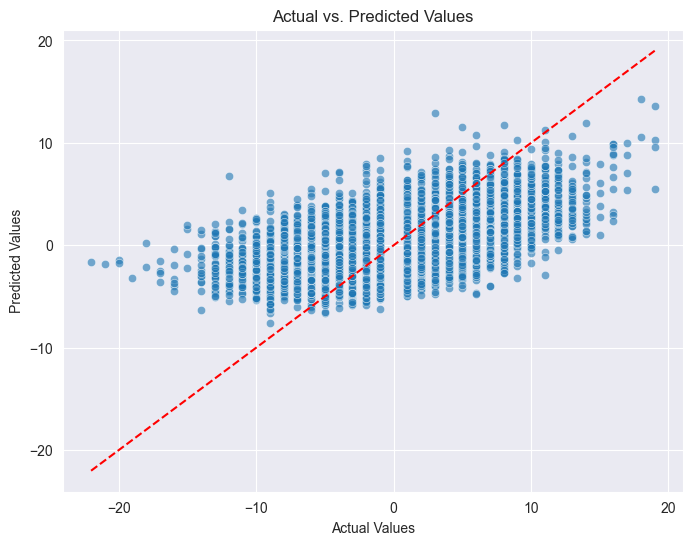

In [15]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.grid(True)
plt.show()

In [16]:
# try to predict a winner based on score_diff
df_xgboost_pred = df_test.assign(
    score_diff_pred = pred_xgb
)
correct_pred = 0
incorrect_pred = 0
for i, row in df_xgboost_pred.iterrows():
    if row['score_diff_pred'] > 0 and y_test[i] > 0:
        correct_pred += 1
    elif row['score_diff_pred'] < 0 and y_test[i] < 0:
        correct_pred += 1
    else:
        incorrect_pred += 1

print("Correct Predictions:", correct_pred, "Incorrect predictions:", incorrect_pred)
print("Percentage of correct pred:", correct_pred / (correct_pred + incorrect_pred))

Correct Predictions: 12756 Incorrect predictions: 5486
Percentage of correct pred: 0.6992654314219932


In [17]:
#Feature Importance
importances = best_estimator.feature_importances_

feature_names = df_train.columns.tolist()

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

feature_importance_df.head(15)

,Feature,Importance
8,bat_home_runs,0.223730
6,bat_doubles,0.155536
9,bat_stolen_bases,0.085096
11,errors_committed,0.085080
7,bat_triples,0.070510
12,stolen_bases,0.064891
10,passed_balls_allowed,0.023452
4,Home_Away,0.013179
34,DEN02,0.012618
5,left_on_base,0.012236


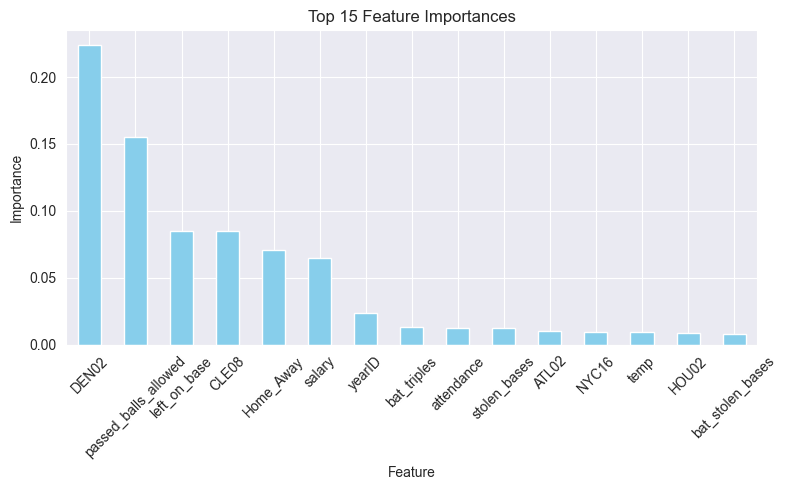

In [23]:
importances = pd.Series(best_estimator.feature_importances_, index=feature_importance_df['Feature'])

top_15 = importances.sort_values(ascending=False).head(15)

# Plot
top_15.plot(kind='bar', figsize=(8, 5), color='skyblue')
plt.title('Top 15 Feature Importances')
plt.ylabel('Importance')
plt.xlabel('Feature')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

